# ML Models Research
Conducting Preliminary research on the different types of Machine Learing models and how to establish a workflow.

## 1) Imports + Set-Up

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay)

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

sns.set_theme(style="whitegrid", palette='Set2')
RANDOM_STATE =42
CLASS_NAMES=['Setosa', 'Versicolor', 'Virginica']

## 2) Loading and preparing the data

In [69]:
df = pd.DataFrame(load_iris().data, columns=load_iris().feature_names)
df['target'] = load_iris().target
df['species'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

In [70]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [72]:
X= df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y = df['target']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

In [87]:
print(f'Dataset: {len(df)} samples, {X.shape[1]} features, {y.nunique()} classes')
print(f'Train: {len(X_train)} samples')
print(f'Test: {len(X_test)} samples')

Dataset: 150 samples, 4 features, 3 classes
Train: 112 samples
Test: 38 samples


In [75]:
df.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


## 3) EDA

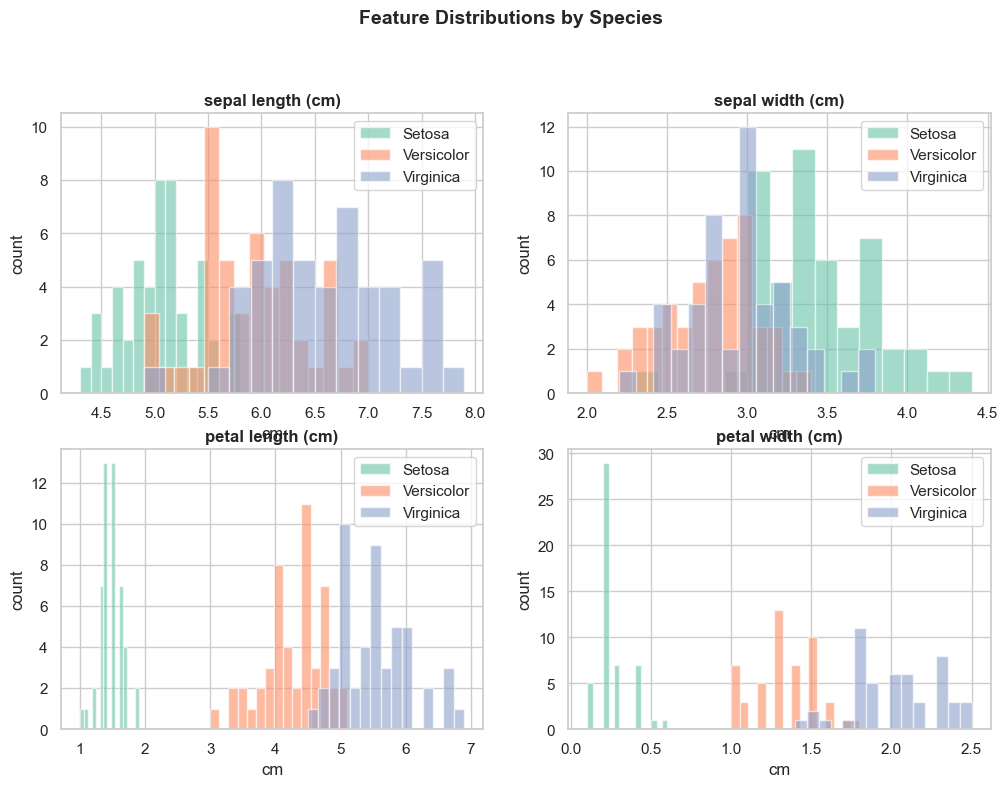

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

for ax, feat in zip(axes.flatten(), features):
    for species in CLASS_NAMES:
        ax.hist(df[df['species'] == species][feat], alpha=0.6, label=species, bins=15)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('cm'); ax.set_ylabel('count')
    ax.legend()

plt.suptitle('Feature Distributions by Species', fontsize=14, fontweight='bold', y=1.01)
plt.show()

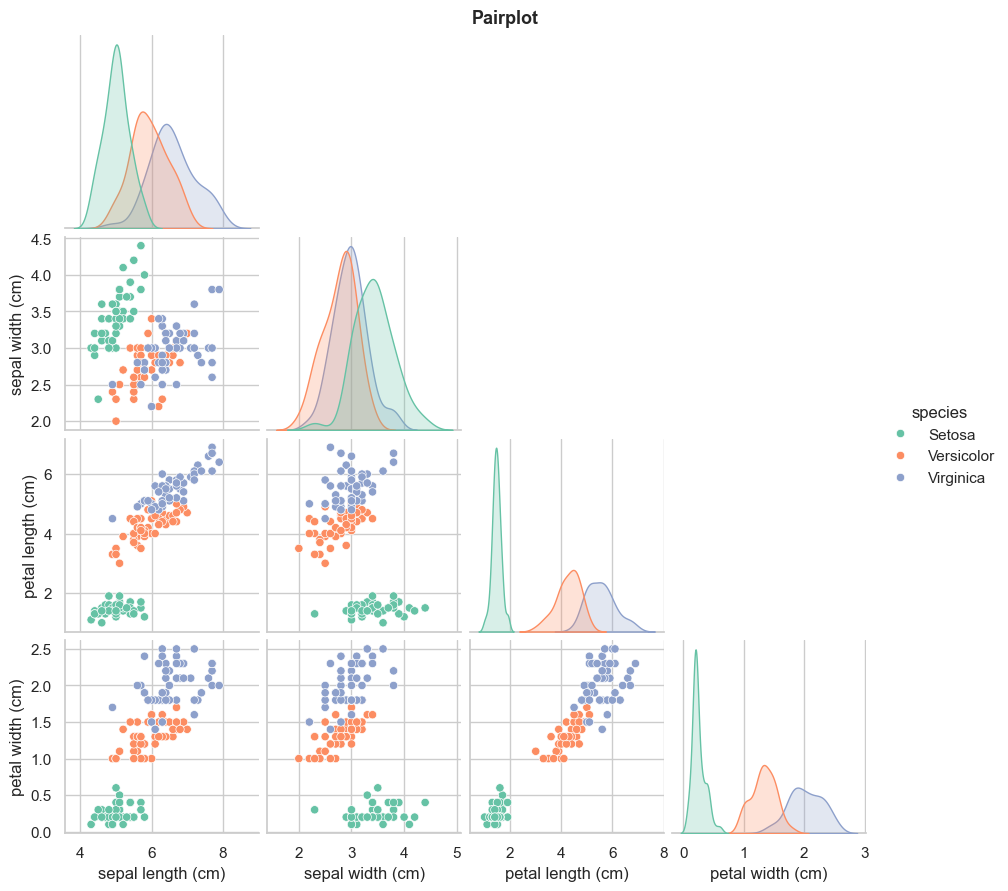

In [77]:
# Pairplot (shows cross-feature relationships)
sns.pairplot(df.drop(columns='target'), hue='species', height=2.2, corner=True)
plt.suptitle('Pairplot', y=1.01, fontsize=13, fontweight='bold')
plt.show()

## 4) Defining the Models

In [78]:

def make_pipeline(clf):
    return Pipeline([('scaler', StandardScaler()), ('clf', clf)])

models = {'Logistic Regression': make_pipeline(LogisticRegression(C=1, max_iter=300, random_state=RANDOM_STATE)),
          'K-Nearest Neighbors': make_pipeline(KNeighborsClassifier(n_neighbors=5)),
          'Support Vector Machine': make_pipeline(SVC(kernel='rbf', C=1, gamma='scale', random_state=RANDOM_STATE)),
          'Decision Tree': make_pipeline(DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)),
          'Random Forest': make_pipeline(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
          'Gradient Boosting': make_pipeline(GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)),
          'Naive Bayes': make_pipeline(GaussianNB()),}

print(f'{len(models)} models used:')
for name in models: print(f'{name}')

7 models used:
Logistic Regression
K-Nearest Neighbors
Support Vector Machine
Decision Tree
Random Forest
Gradient Boosting
Naive Bayes


## 5) Cross validation on training set:

In [79]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<24}  CV acc: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')

Logistic Regression       CV acc: 96.48% ± 5.08%
K-Nearest Neighbors       CV acc: 96.44% ± 3.28%
Support Vector Machine    CV acc: 96.48% ± 5.08%
Decision Tree             CV acc: 93.75% ± 2.17%
Random Forest             CV acc: 96.44% ± 3.28%
Gradient Boosting         CV acc: 95.57% ± 2.75%
Naive Bayes               CV acc: 97.35% ± 3.50%


## 6) Test-Set Evaluation

In [80]:

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds= model.predict(X_test)
    acc= accuracy_score(y_test, preds)
    fitted_models[name]= (model, preds)
    results.append({'Model': name, 'Test Accuracy': acc})

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results_df['Test Accuracy %'] = (results_df['Test Accuracy'] * 100).round(2)
results_df[['Model', 'Test Accuracy %']]

,Model,Test Accuracy %
0,Gradient Boosting,97.37
1,Support Vector Machine,94.74
2,Logistic Regression,92.11
3,K-Nearest Neighbors,92.11
4,Decision Tree,92.11
5,Random Forest,92.11
6,Naive Bayes,92.11


## 7) Visualizations

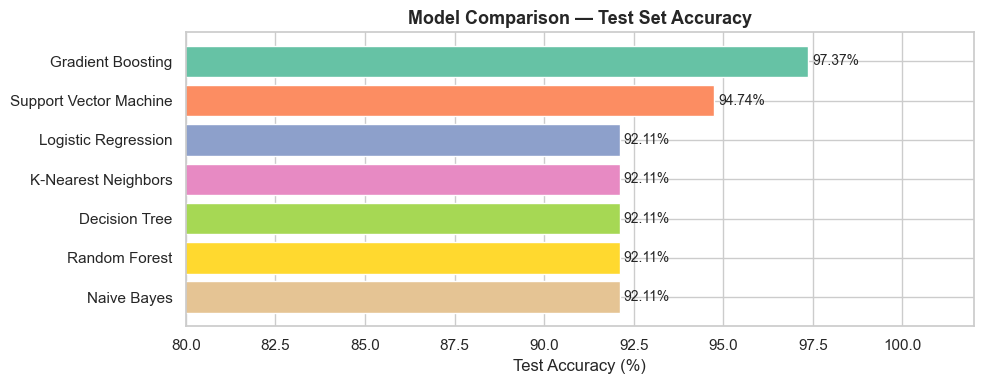

In [81]:
#Accuracy comparison bar chart

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(results_df['Model'], results_df['Test Accuracy %'],
               color=sns.color_palette('Set2', len(results_df)))
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
ax.set_xlim(80, 102)
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Model Comparison — Test Set Accuracy', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

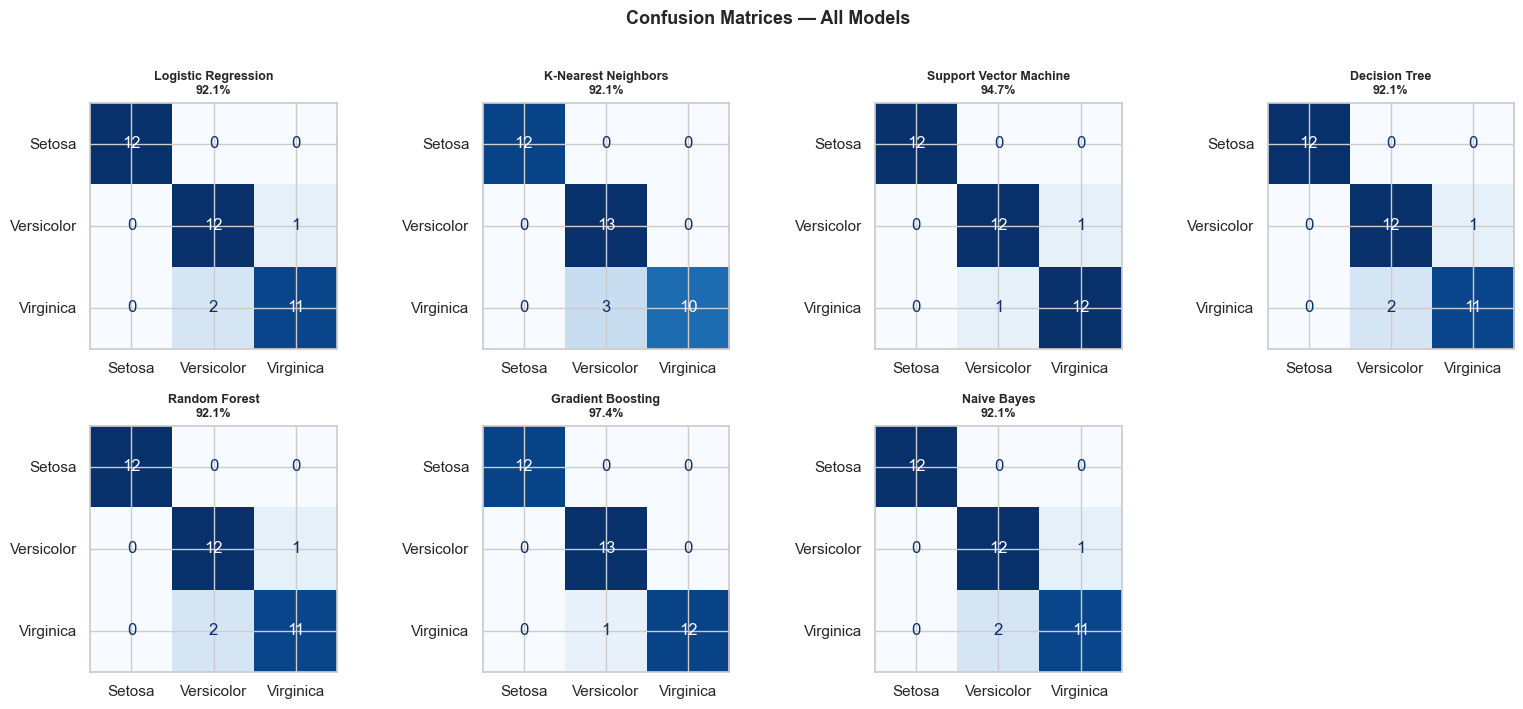

In [82]:
n = len(models)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes = axes.flatten()

for i, (name, (model, preds)) in enumerate(fitted_models.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, preds) * 100
    axes[i].set_title(f'{name}\n{acc:.1f}%', fontsize=9, fontweight='bold')
    axes[i].set_xlabel(''); axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

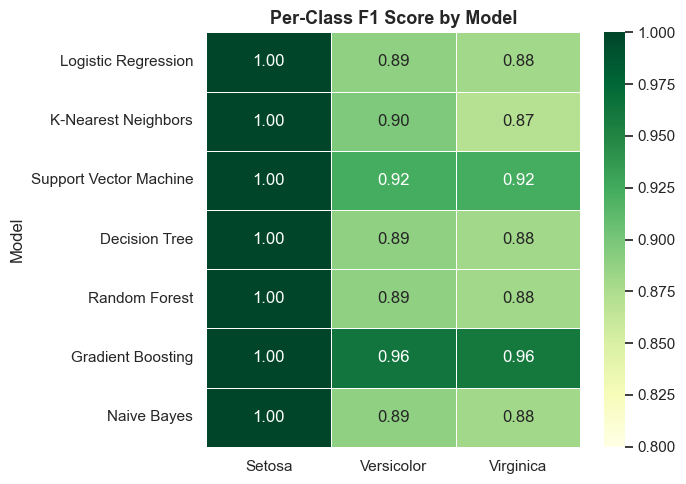

In [83]:
f1_rows = []
for name, (model, preds) in fitted_models.items():
    report = classification_report(y_test, preds, target_names=CLASS_NAMES, output_dict=True)
    f1_rows.append({'Model': name,
                    'Setosa':     report['Setosa']['f1-score'],
                    'Versicolor': report['Versicolor']['f1-score'],
                    'Virginica':  report['Virginica']['f1-score']})

f1_df = pd.DataFrame(f1_rows).set_index('Model')

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(f1_df, annot=True, fmt='.2f', cmap='YlGn', vmin=0.8, vmax=1.0,
            linewidths=0.5, ax=ax)
ax.set_title('Per-Class F1 Score by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

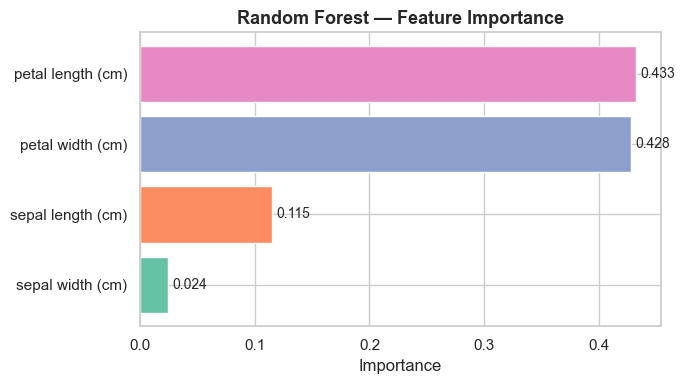

In [84]:
# ── 7e: Random Forest feature importance ─────────────────
rf_model = fitted_models['Random Forest'][0].named_steps['clf']
importances = rf_model.feature_importances_
feat_names  = X.columns.tolist()

fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})\
          .sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(fi_df['Feature'], fi_df['Importance'],
               color=sns.color_palette('Set2', len(fi_df)))
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

C:\Users\asmis\AppData\Local\Temp\ipykernel_18616\1270492533.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cv_summary['Model'], rotation=25, ha='right')


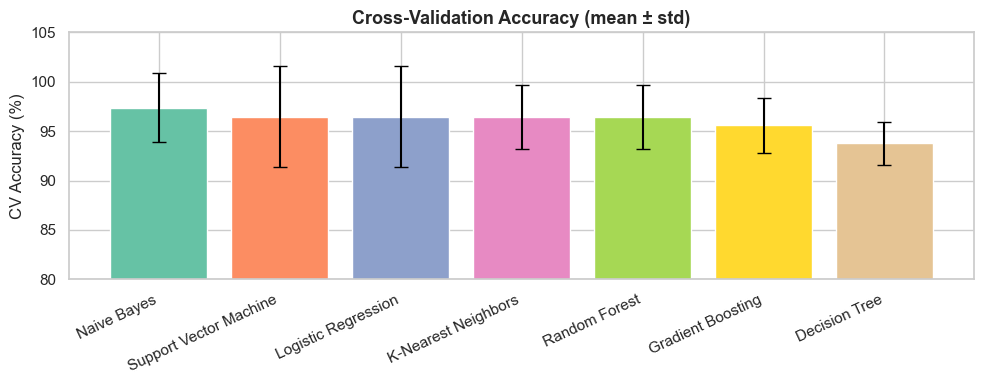

In [85]:
# ── 7f: CV mean ± std summary bar ────────────────────────
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'CV Mean': [v.mean() * 100 for v in cv_results.values()],
    'CV Std':  [v.std()  * 100 for v in cv_results.values()],
}).sort_values('CV Mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cv_summary['Model'], cv_summary['CV Mean'],
       yerr=cv_summary['CV Std'], capsize=5,
       color=sns.color_palette('Set2', len(cv_summary)),
       error_kw={'elinewidth': 1.5})
ax.set_ylabel('CV Accuracy (%)')
ax.set_title('Cross-Validation Accuracy (mean ± std)', fontsize=13, fontweight='bold')
ax.set_xticklabels(cv_summary['Model'], rotation=25, ha='right')
ax.set_ylim(80, 105)
plt.tight_layout()
plt.show()

## 8) Summary

In [86]:
print('FINAL RESULTS SUMMARY')
for _, row in results_df.iterrows():
    print(f"{row['Model']:<24} {row['Test Accuracy %']:5.2f}%")
best = results_df.iloc[0]
print(f"\nBest model: {best['Model']} ({best['Test Accuracy %']}% test acc)")

FINAL RESULTS SUMMARY
Gradient Boosting        97.37%
Support Vector Machine   94.74%
Logistic Regression      92.11%
K-Nearest Neighbors      92.11%
Decision Tree            92.11%
Random Forest            92.11%
Naive Bayes              92.11%

Best model: Gradient Boosting (97.37% test acc)
